In [1]:
from forget.model import Llama2Wrapper, Llama3Wrapper
from forget.chat import Chat
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
df_train = pd.read_csv("store/presidents/good_train.csv")
df_good_val = pd.read_csv("store/presidents/good_val.csv")

MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."

def format_mcq_prompt(row):
    return (
        f"{row['q']}\n"
        f"A) {row['a']}\n"
        f"B) {row['b']}\n"
        f"C) {row['c']}\n"
        f"D) {row['d']}"
    )

TARGET = "Barack Obama"
TARGET

'Barack Obama'

In [3]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# calculate steering vector

In [8]:
def extract_activations(llm, chat):
    llm.reset_all()
    llm.forward_from_chat(chat)
    num_layers = len(llm.model.model.layers)
    layer_acts = []
    for i in range(num_layers):
        act = llm.get_last_activations(i).detach().cpu()
        if act.dim() == 2:
            act = act.unsqueeze(0)
        layer_acts.append(act[:, -1, :])
    return t.stack(layer_acts)  # (num_layers, 1, hidden_dim)

def collect_activations(llm, df, system_prompt=MCQ_SYSTEM):
    all_acts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="collecting activations"):
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_mcq_prompt(row))
        chat.add_assistant_message(row["ans"])
        acts = extract_activations(llm, chat)
        all_acts.append(acts)
    return t.stack(all_acts)  # (n_samples, num_layers, 1, hidden_dim)

In [9]:
target_mask = df_train["president"] == TARGET
f"Target: {TARGET} — {target_mask.sum()} forget, {(~target_mask).sum()} retain"

'Target: Barack Obama — 3937 forget, 7914 retain'

In [ ]:
os.makedirs("store/llama3_pres", exist_ok=True)

# collect activations on full train set
activations = collect_activations(llm, df_train)
t.save(activations, "store/llama3_pres/activations.pt")

In [10]:
# steering = retain (rest) - forget (target)
mask = t.tensor(target_mask.values)
forget_acts = activations[mask].mean(dim=0)
retain_acts = activations[~mask].mean(dim=0)
steer = retain_acts - forget_acts
t.save(steer, "store/llama3_pres/steer.pt")

# run steered benchmark

In [11]:
ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    return raw[idx + len(ASSISTANT_HEADER):].strip() if idx != -1 else raw.strip()

def parse_answer(response: str) -> str:
    idx = response.rfind(ASSISTANT_HEADER)
    tail = response[idx + len(ASSISTANT_HEADER):] if idx != -1 else response
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def make_eval_set(df, n_per_pres=None):
    if n_per_pres:
        return pd.concat([g.sample(min(len(g), n_per_pres), random_state=42) for _, g in df.groupby("president")]).reset_index(drop=True)
    return df

def evaluate_row(llm, row):
    chat = Chat(system_prompt=MCQ_SYSTEM)
    chat.add_user_message(format_mcq_prompt(row))
    raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
    parsed = parse_answer(raw)
    correct = int(parsed == row["ans"].upper())
    return raw, parsed, correct

In [12]:
def _normalize_layers(layer):
    if isinstance(layer, int):
        return [layer]
    return list(layer)

def evaluate_steered(llm, df, steer_vec, source_layer=12, target_layer=12, scale=4.0, steer_type="contrast"):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers), f"source ({len(src_layers)}) and target ({len(tgt_layers)}) must be same length"

    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for i, row in pbar:
        chat = Chat(system_prompt=MCQ_SYSTEM)
        chat.add_user_message(format_mcq_prompt(row))

        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_add_activations(tl, scale * steer_vec[sl])
        raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
        llm.reset_all()

        parsed = parse_answer(raw)
        correct = int(parsed == row["ans"].upper())
        rows.append({
            "president": row["president"],
            "question": row["q"],
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["ans"].upper(),
            "correct": correct,
        })
        acc = sum(r["correct"] for r in rows) / len(rows)
        pbar.set_description(f"acc: {acc:.1%}")
    return pd.DataFrame(rows)

In [ ]:
steer = t.load("store/llama3_pres/steer.pt").to(llm.device)
steer_contrast = steer / steer.norm(dim=-1, keepdim=True)

steer_random = t.randn_like(steer)
steer_random = steer_random / steer_random.norm(dim=-1, keepdim=True)

In [22]:
df_eval = make_eval_set(df_good_val, 25)

# scales = np.arange(0, 2, 0.5).tolist()
scales = [0, 5, 10, 20, 40]
source_layers = [16]
target_layers = [16]
steering_vectors = {
    "contrast": steer_contrast,
    "random": steer_random,
}

all_dfs = []
for steer_type, steer_vec in steering_vectors.items():
    for src, tgt in zip(source_layers, target_layers):
        for s in scales:
            contrast_df = evaluate_steered(
                llm, df_eval, steer_vec=steer_vec,
                source_layer=src, target_layer=tgt,
                scale=s, steer_type=steer_type,
            )
            all_dfs.append(contrast_df)

steered_df = pd.concat(all_dfs, ignore_index=True)
steered_df.to_csv("store/llama3_pres/steered.csv", index=False)

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

# Plots

### Performance

In [23]:
steered_df = pd.read_csv("store/llama3_pres/steered.csv")

In [24]:
def acc_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "correct"].mean(), df.loc[~mask, "correct"].mean()

def empty_rate_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "parsed"].isna().mean(), df.loc[~mask, "parsed"].isna().mean()

def plot_perf(steered_df, source_layer, target_layer, label, target=TARGET):
    scales = sorted(steered_df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (steered_df["source_layer"].astype(str) == src_str) & (steered_df["target_layer"].astype(str) == tgt_str)

    series = {k: [] for k in ["a_acc_c","o_acc_c","a_emp_c","o_emp_c","a_acc_r","o_acc_r","a_emp_r","o_emp_r"]}
    for s in scales:
        base = mask_layer & (steered_df["scale"] == s)
        for suffix, st in [("c", "contrast"), ("r", "random")]:
            sub = steered_df[base & (steered_df["steer_type"] == st)]
            a_acc, o_acc = acc_by_president(sub, target)
            a_emp, o_emp = empty_rate_by_president(sub, target)
            series[f"a_acc_{suffix}"].append(a_acc)
            series[f"o_acc_{suffix}"].append(o_acc)
            series[f"a_emp_{suffix}"].append(a_emp)
            series[f"o_emp_{suffix}"].append(o_emp)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, ya, yo, title in [
        (ax1, "acc", series["a_acc_c"], series["o_acc_c"], f"Accuracy — {label}"),
        (ax2, "emp", series["a_emp_c"], series["o_emp_c"], f"%Malformed — {label}"),
    ]:
        ax.plot(scales, ya, color="darkred", label=f"{target} (contrast)")
        ax.plot(scales, series[f"a_{metric}_r"], color="darkred", linestyle="--", label=f"{target} (random)")
        ax.plot(scales, yo, color="black", label="others (contrast)")
        ax.plot(scales, series[f"o_{metric}_r"], color="black", linestyle="--", label="others (random)")
        ax.set_xlabel("scale")
        ax.set_ylabel("accuracy" if metric == "acc" else "% malformed")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

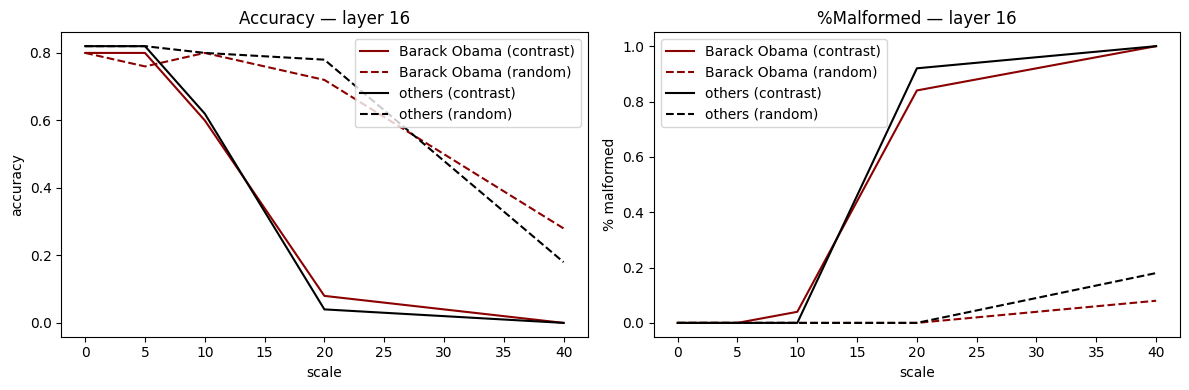

In [26]:
plot_perf(steered_df, 16, 16, "layer 16")

### FGD

In [28]:
# # PGD(layer) = ||mean(v_i)|| / mean(||v_i||)
# # PGD=1 → all samples agree on direction; PGD→0 → no consistent direction.

# activations = t.load("store/llama3_pres/activations.pt")
# mask = t.tensor((df_train["president"] == TARGET).values)

# forget = activations[mask][:, :, 0, :]  # (n_forget, num_layers, hidden_dim)
# retain = activations[~mask][:, :, 0, :]
# steer = retain.mean(dim=0, keepdim=True) - forget.mean(dim=0, keepdim=True)

# num_layers = forget.shape[1]

# def compute_pgd(vecs_by_layer):
#     pgd = t.zeros(num_layers)
#     for layer in range(num_layers):
#         vecs = vecs_by_layer[:, layer, :]
#         pgd[layer] = vecs.mean(dim=0).norm() / vecs.norm(dim=1).mean()
#     return pgd

# pgd_forget = compute_pgd(forget)
# pgd_retain = compute_pgd(retain)
# pgd_steer = compute_pgd(steer)

# fig, ax = plt.subplots(figsize=(8, 3))
# layers = range(num_layers)
# ax.plot(layers, pgd_forget.numpy(), color="red", label="forget")
# ax.plot(layers, pgd_retain.numpy(), color="green", label="retain")
# ax.plot(layers, pgd_steer.numpy(), color="black", label="steer (retain-forget)")
# ax.set_xlabel("Layer")
# ax.set_ylabel("PGD")
# ax.set_title(f"PGD across Layers — target: {TARGET}")
# ax.set_xlim(0, num_layers - 1)
# ax.set_ylim(0, 1)
# ax.legend(loc="lower right", frameon=False)
# plt.show()

In [ ]:
# steered_df[steered_df["scale"] == 30]